In [ ]:
import pandas as pd

# 1- Data integration/Charger le dataset
# Action concrète:
# On importe le fichier CSV ;
# On transforme les données en tableau exploitable.

# Problème potentiel:
# fichier introuvable ;
# mauvais séparateur ;
# encodage incorrect.

df = pd.read_csv("C:/Users/amara/Cours_python_Mr_Souleymane/dataset_ventes_fictives.csv")


In [5]:
df

,ID_Vente,Client,Produit,Quantite,Prix_Unitaire,Montant_Total,Date_Vente,Ville
0,1,Allison Cantu,Souris,16,1459,23344,2025-07-05,Kindia
1,2,Marissa Smith,Ordinateur,2,971,1942,2025-01-29,Kindia
2,3,Steven Baker,Écran,7,1565,10955,2025-01-27,Boké
3,4,Steven Francis,Imprimante,16,358,5728,2025-01-04,Labé
4,5,Sue Jimenez,Ordinateur,6,70,420,2025-02-25,Conakry
...,...,...,...,...,...,...,...,...
495,496,Traci Hart,Casque,19,1085,20615,2025-12-09,Labé
496,497,Timothy Francis,Disque SSD,13,1768,22984,2025-12-21,Kankan
497,498,Blake Morrison,Imprimante,19,1464,27816,2025-04-02,Conakry
498,499,Dr. Craig Johnson,Ordinateur,19,1785,33915,2025-07-28,Nzérékoré


In [ ]:
# 2- Data selection

# Supposons qu’on veut analyser :
# Produit
# Quantité
# Prix
# Ville

# Action concrète:
# On garde uniquement les informations importantes pour l’analyse.

# Problème potentiel:
# supprimer une colonne importante par erreur.

selection = df[['Produit', 'Quantite', 'Prix_Unitaire','Date_Vente', 'Ville']]


In [7]:
selection

,Produit,Quantite,Prix_Unitaire,Ville
0,Souris,16,1459,Kindia
1,Ordinateur,2,971,Kindia
2,Écran,7,1565,Boké
3,Imprimante,16,358,Labé
4,Ordinateur,6,70,Conakry
...,...,...,...,...
495,Casque,19,1085,Labé
496,Disque SSD,13,1768,Kankan
497,Imprimante,19,1464,Conakry
498,Ordinateur,19,1785,Nzérékoré


In [8]:
#  3- Data cleaning

# Supprimer :
# les valeurs manquantes ;
# les doublons ;
# les erreurs.

# Action concrète:
# On rend les données propres et fiables.

# Problème potentiel:
# données incohérentes ;
# lignes dupliquées ;
# valeurs nulles.

df.isnull().sum()

df = df.drop_duplicates()

df.dtypes

ID_Vente          int64
Client           object
Produit          object
Quantite          int64
Prix_Unitaire     int64
Montant_Total     int64
Date_Vente       object
Ville            object
dtype: object

In [9]:
df

,ID_Vente,Client,Produit,Quantite,Prix_Unitaire,Montant_Total,Date_Vente,Ville
0,1,Allison Cantu,Souris,16,1459,23344,2025-07-05,Kindia
1,2,Marissa Smith,Ordinateur,2,971,1942,2025-01-29,Kindia
2,3,Steven Baker,Écran,7,1565,10955,2025-01-27,Boké
3,4,Steven Francis,Imprimante,16,358,5728,2025-01-04,Labé
4,5,Sue Jimenez,Ordinateur,6,70,420,2025-02-25,Conakry
...,...,...,...,...,...,...,...,...
495,496,Traci Hart,Casque,19,1085,20615,2025-12-09,Labé
496,497,Timothy Francis,Disque SSD,13,1768,22984,2025-12-21,Kankan
497,498,Blake Morrison,Imprimante,19,1464,27816,2025-04-02,Conakry
498,499,Dr. Craig Johnson,Ordinateur,19,1785,33915,2025-07-28,Nzérékoré


In [10]:
# 4- Data transformation

# Transformer les données pour faciliter l’analyse.
# Par exemple :
# convertir la date ;
# créer une colonne Mois.

# Action concrète:
# On prépare les données pour les analyses futures.

# Problème potentiel:
# mauvais format de date.

df['Date_Vente'] = pd.to_datetime(df['Date_Vente'])


# Extraire le mois
df['Mois'] = df['Date_Vente'].dt.month


df[['Date_Vente', 'Mois']].head()

,Date_Vente,Mois
0,2025-07-05,7
1,2025-01-29,1
2,2025-01-27,1
3,2025-01-04,1
4,2025-02-25,2


In [11]:
# 5- Data mining

# Découvrir des tendances ou connaissances cachées.
# Exemple :
# Quel produit se vend le plus ?

# Action concrète:
# identifier les produits les plus vendus ;
# trouver les villes ayant le plus d’achats.

# Problème potentiel:
# mauvaise interprétation des résultats.

ventes = df.groupby('Produit')['Quantite'].sum()

ventes

In [12]:
ventes

Produit
Casque        577
Clavier       408
Disque SSD    361
Imprimante    519
Ordinateur    479
Routeur       461
Souris        644
Tablette      501
Téléphone     593
Écran         424
Name: Quantite, dtype: int64

In [16]:
# 6- Pattern evaluation
# Vérifier si les résultats obtenus sont utiles.

# Action concrète:
# On valide les tendances découvertes.

# Problème potentiel:
# tirer de mauvaises conclusions.

top_produit = ventes.idxmax()


print("Produit le plus vendu :", top_produit)

Produit le plus vendu : Souris


In [17]:
top_produit

'Souris'

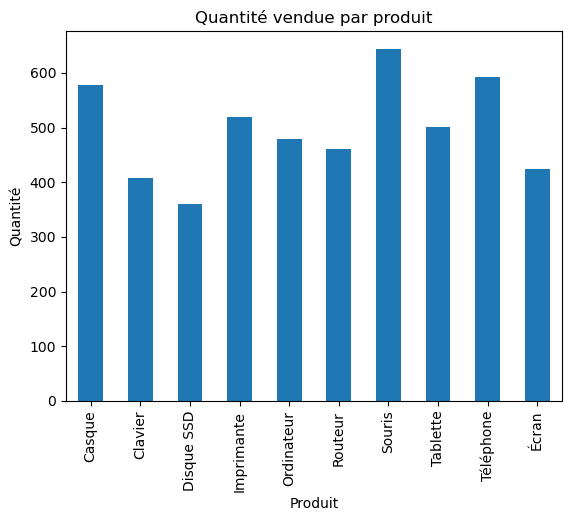

In [18]:
# 7- Knowledge presentation
# Présenter les résultats avec des graphiques.

# Action concrète:
# On transforme les résultats en graphiques faciles à comprendre.

# Problème potentiel:
# graphique peu lisible.

import matplotlib.pyplot as plt

ventes.plot(kind='bar')

plt.title("Quantité vendue par produit")
plt.xlabel("Produit")
plt.ylabel("Quantité")
plt.show()